# Task 5: Content Rating & Genre Analysis

## Objective

The objective of this task is to analyze Netflix content ratings and genres to understand audience targeting and content distribution. This analysis helps identify the most common ratings, popular genres, and how ratings vary between Movies and TV Shows.

## Libraries Used

- Pandas
- Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Cleaned_Data/Netflix_Cleaned.csv")

df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [4]:
df[["rating", "listed_in"]].isnull().sum()

rating       0
listed_in    0
dtype: int64

## Rating Analysis

In [5]:
ratings = df["rating"].value_counts()

ratings

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

## Visualization 1: Content Ratings Distribution

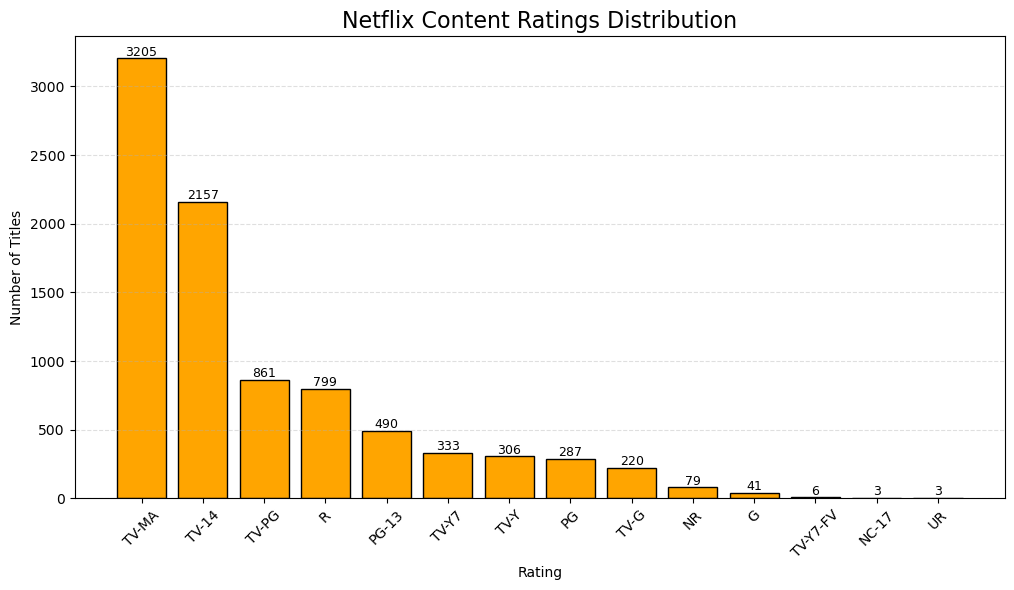

In [6]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    ratings.index,
    ratings.values,
    color="orange",
    edgecolor="black"
)

plt.title("Netflix Content Ratings Distribution", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        int(bar.get_height()),
        ha="center",
        fontsize=9
    )

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig(
    "Images/Task5_Rating_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

The analysis shows that **TV-MA** is the most common content rating on Netflix, followed by **TV-14**.

This indicates that Netflix primarily targets mature and teenage audiences while still offering content suitable for children and families through ratings such as TV-Y, TV-G, and PG.

## Genre Analysis


In [7]:
df["listed_in"].head()

0                                        Documentaries
1    Crime TV Shows, International TV Shows, TV Act...
2                   TV Dramas, TV Horror, TV Mysteries
3                   Children & Family Movies, Comedies
4     Dramas, Independent Movies, International Movies
Name: listed_in, dtype: object

In [8]:
genres = (
    df["listed_in"]
    .str.split(",")
    .explode()
    .str.strip()
)

genres.head(10)

0               Documentaries
1              Crime TV Shows
1      International TV Shows
1       TV Action & Adventure
2                   TV Dramas
2                   TV Horror
2                TV Mysteries
3    Children & Family Movies
3                    Comedies
4                      Dramas
Name: listed_in, dtype: object

In [9]:
genre_counts = genres.value_counts()

genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

## Visualization 2: Top 10 Netflix Genres

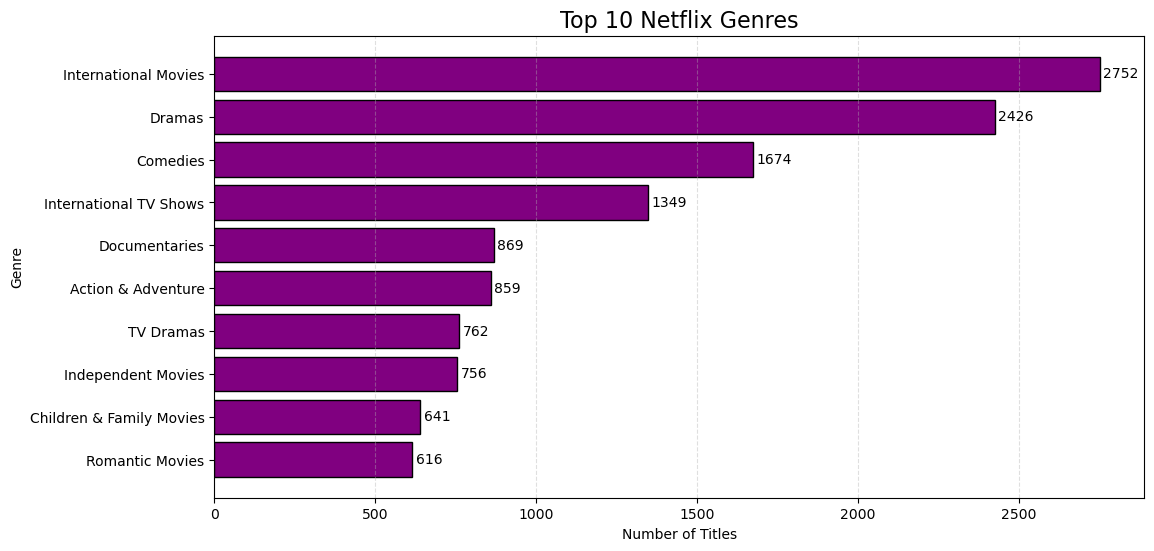

In [10]:
plt.figure(figsize=(12,6))

top_genres = genre_counts.head(10)

bars = plt.barh(
    top_genres.index,
    top_genres.values,
    color="purple",
    edgecolor="black"
)

plt.title("Top 10 Netflix Genres", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center",
        fontsize=10
    )

# Highest value at the top
plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig(
    "Images/Task5_Genre_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

The analysis shows that **International Movies** is the most common genre on Netflix, followed by **Dramas** and **Comedies**.

This suggests that Netflix emphasizes globally accessible content while maintaining a diverse catalog across multiple genres to attract audiences from different regions and preferences.

## Ratings by Content Type

In [11]:
rating_type = pd.crosstab(df["type"], df["rating"])

rating_type

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,41,3,75,287,490,797,1427,126,2062,540,131,139,5,3
TV Show,0,0,4,0,0,2,730,94,1143,321,175,194,1,0


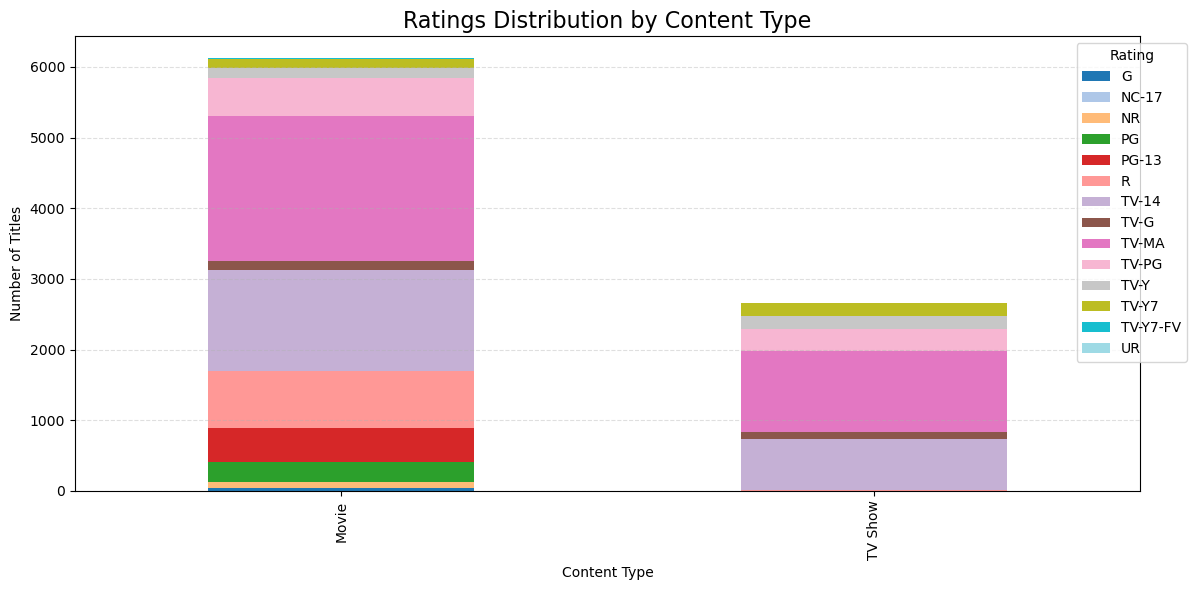

In [12]:
rating_type.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="tab20"
)

plt.title("Ratings Distribution by Content Type", fontsize=16)
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Rating", bbox_to_anchor=(1.05,1))

plt.tight_layout()

plt.savefig(
    "Images/Task5_Rating_vs_ContentType.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

The comparison shows that Movies have a wider variety of ratings, while TV Shows are primarily concentrated in the TV-MA and TV-14 categories.

This indicates that Netflix produces Movies for audiences of all age groups, whereas its TV Show catalog is largely focused on mature and teenage viewers.

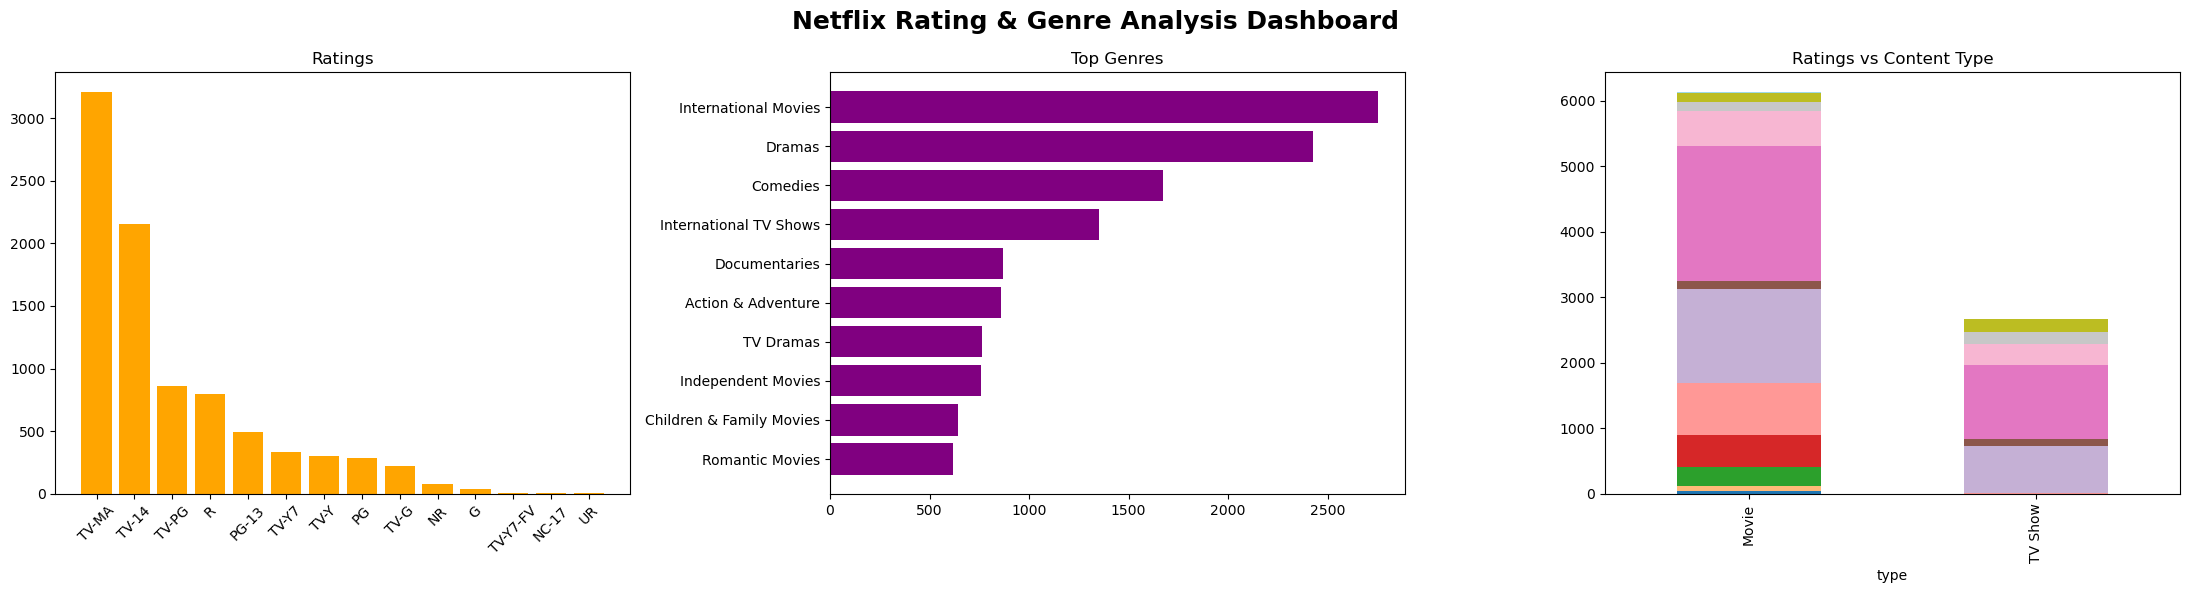

In [13]:
fig, ax = plt.subplots(1,3, figsize=(22,6))

# Chart 1
ax[0].bar(
    ratings.index,
    ratings.values,
    color="orange"
)
ax[0].set_title("Ratings")
ax[0].tick_params(axis="x", rotation=45)

# Chart 2
ax[1].barh(
    top_genres.index,
    top_genres.values,
    color="purple"
)
ax[1].invert_yaxis()
ax[1].set_title("Top Genres")

# Chart 3
rating_type.plot(
    kind="bar",
    stacked=True,
    ax=ax[2],
    colormap="tab20"
)

ax[2].set_title("Ratings vs Content Type")
ax[2].legend().remove()

plt.suptitle(
    "Netflix Rating & Genre Analysis Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Images/Task5_Final_Dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Findings

- TV-MA is the most common Netflix content rating.
- TV-14 is the second most common rating.
- International Movies is the largest genre.
- Dramas and Comedies are also highly represented.
- Movies have a wider range of ratings than TV Shows.
- TV Shows are primarily targeted toward mature audiences.

# Conclusion

The rating and genre analysis shows that Netflix primarily targets mature audiences while maintaining a diverse catalog of genres. International Movies, Dramas, and Comedies dominate the platform, reflecting Netflix's strategy of serving a global audience with varied entertainment preferences.

This analysis demonstrates how combining rating data with genre information provides deeper insights into Netflix's content strategy and audience segmentation.